#Cliff Walking (Random Agent)
A 4×12 gridworld where the agent must navigate from Start to Goal while avoiding a cliff.
## The Grid
##Row 0:  [ ][ ][ ][ ][ ][ ][ ][ ][ ][ ][ ][ ]
##Row 1:  [ ][ ][ ][ ][ ][ ][ ][ ][ ][ ][ ][ ]
##Row 2:  [ ][ ][ ][ ][ ][ ][ ][ ][ ][ ][ ][ ]
##Row 3:  [S][C][C][C][C][C][C][C][C][C][C][G]

 S = Start [3,0], G = Goal [3,11], C = Cliff [3, 1..10]

## Action Space:  Discrete(4)
There are exactly 4 possible actions
 | Value | Action     |
 |-------|------------|
 | 0     | Move Up    |
 | 1     | Move Right |
 | 2     | Move Down  |
 | 3     | Move Left  |

## Observation Space: Discrete(48)
The observation is a value representing the player's current position as current_row * ncols + current_col

Each grid cell maps to a unique integer:

- observation = current_row * 12 + current_col
- Start [3, 0]  → 3 * 12 + 0  = 36
- Goal  [3, 11] → 3 * 12 + 11 = 47

- There are 3 × 12 + 1 = 37 possible states the player can actually be in
- The cliff and goal are excluded from reachable mid-episode states. But the space is still declared as Discrete(48) (total grid cells).

## Rewards
 | Situation         | Reward |
 |-------------------|--------|
 | Every normal step | -1     |
 | Step into cliff   | -100   |
#
 This creates a trade-off:
   - Safe path (top row): longer but avoids -100 penalty
   - Risky path (bottom row): shorter but risks falling off cliff
 This is the classic SARSA vs Q-Learning comparison scenario.

## Episode End (Termination)
Episode ends when agent reaches state 47 (Goal at [3, 11]) or truncated.

## Info Dictionary
 step() and reset() return info = {"p": 1.0}
 "p" is the transition probability — always 1.0 (deterministic by default)

## Quick Reference
 | Property        | Value                        |
 |-----------------|------------------------------|
 | Grid size       | 4 × 12                       |
 | Actions         | 4 (up / right / down / left) |
 | Total states    | 48                           |
 | Start state     | 36                           |
 | Goal state      | 47                           |
 | Normal reward   | -1 per step                  |
 | Cliff penalty   | -100                         |
 | Stochastic?     | No (unless is_slippery=True) |

In [ ]:
!pip install gymnasium
!pip install opencv-python

In [ ]:
import numpy as np
import gymnasium as gym
import cv2
import time
from IPython.display import display, Image, clear_output
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
import ipywidgets as widgets

#Text mod

In [ ]:
env = gym.make("CliffWalking-v1", render_mode="ansi")
flag = False
state = env.reset()

In [ ]:
while not flag:
  print(env.render())
  action = env.action_space.sample()
  print(f'State = {state}, Action = {["up","right","down","left"][action]}')
  state, reward, terminated, truncated, info = env.step(action)
  flag = terminated or truncated
env.close()

Streaming output truncated to the last 5000 lines.

State = 3, Action = right
o  o  o  o  x  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
o  C  C  C  C  C  C  C  C  C  C  T


State = 4, Action = right
o  o  o  o  o  x  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
o  C  C  C  C  C  C  C  C  C  C  T


State = 5, Action = left
o  o  o  o  x  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
o  C  C  C  C  C  C  C  C  C  C  T


State = 4, Action = right
o  o  o  o  o  x  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
o  C  C  C  C  C  C  C  C  C  C  T


State = 5, Action = down
o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  x  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
o  C  C  C  C  C  C  C  C  C  C  T


State = 17, Action = right
o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  x  o  o  o  o  o
o  o  o  o  o

#Visualization

In [ ]:

#https://github.com/rajtilakls2510/reinforcement_learning/tree/part_3

# Creates cliff walking grid
def initialize_frame():
    width, height = 600, 200
    img = np.ones(shape=(height, width, 3)) * 255.0
    margin_horizontal = 6
    margin_vertical = 2

    # Vertical Lines
    for i in range(13):
        img = cv2.line(img, (49 * i + margin_horizontal, margin_vertical),
                       (49 * i + margin_horizontal, 200 - margin_vertical), color=(0, 0, 0), thickness=1)

    # Horizontal Lines
    for i in range(5):
        img = cv2.line(img, (margin_horizontal, 49 * i + margin_vertical),
                       (600 - margin_horizontal, 49 * i + margin_vertical), color=(0, 0, 0), thickness=1)

    # Cliff Box
    img = cv2.rectangle(img, (49 * 1 + margin_horizontal + 2, 49 * 3 + margin_vertical + 2),
                        (49 * 11 + margin_horizontal - 2, 49 * 4 + margin_vertical - 2), color=(255, 0, 255),
                        thickness=-1)
    img = cv2.putText(img, text="Cliff", org=(49 * 5 + margin_horizontal, 49 * 4 + margin_vertical - 10),
                      fontFace=cv2.FONT_HERSHEY_SIMPLEX, fontScale=1, color=(255, 255, 255), thickness=2)

    # Goal
    frame = cv2.putText(img, text="G", org=(49 * 11 + margin_horizontal + 10, 49 * 4 + margin_vertical - 10),
                        fontFace=cv2.FONT_HERSHEY_SIMPLEX, fontScale=1, color=(0, 0, 0), thickness=2)
    # Start
    # frame = cv2.putText(img, text="S", org=(49 * 0 + margin_horizontal + 10, 49 * 4 + margin_vertical - 10),
    #                     fontFace=cv2.FONT_HERSHEY_SIMPLEX, fontScale=1, color=(0, 0, 0), thickness=2)
    return frame


# puts the agent at a state
def put_agent(img, state):
    margin_horizontal = 6
    margin_vertical = 2
    row, column = np.unravel_index(indices=state, shape=(4, 12))
    cv2.putText(img, text="A", org=(49 * column + margin_horizontal + 10, 49 * (row + 1) + margin_vertical - 10),
                fontFace=cv2.FONT_HERSHEY_SIMPLEX, fontScale=1, color=(0, 0, 0), thickness=2)
    return img

display_handle = display(Image(data=b''), display_id=True)
def show_frame(img):
    _, buf = cv2.imencode(".jpg", img)
    display_handle.update(Image(data=buf.tobytes()))

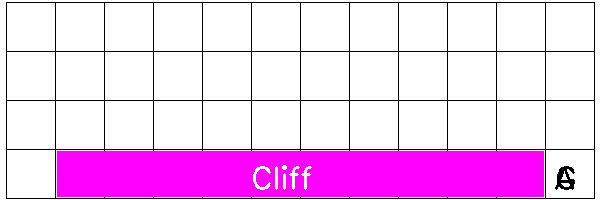

In [ ]:
env = gym.make("CliffWalking-v1", render_mode="rgb_array")
flag = False
state, info = env.reset()
frame = initialize_frame()

step=0
#MAX_Step=100
while not flag: #and step<MAX_Step:
  action = env.action_space.sample()
  state, reward, terminated, truncated, info = env.step(action)
  flag = terminated or truncated
  #step+=1
  frame2 = put_agent(frame.copy(),state)
  show_frame(frame2)
  time.sleep(0.1)
env.close()